### Adam by hand, bias correction, warmup, schedules, LR vs width

In [1]:
import math
import os
import urllib.request

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F

device = "cuda" if torch.cuda.is_available() else "cpu"
os.makedirs("plots", exist_ok=True)
print("device:", device)

device: cuda


## Part 1 - Adam by hand vs PyTorch

In [2]:
lr, beta1, beta2, eps = 1e-3, 0.9, 0.999, 1e-8
w0 = 1.0
grads = [0.5, -0.3, 0.8, 0.1, -0.6]

# by hand
w, m, v = w0, 0.0, 0.0
hand = []
for t, g in enumerate(grads, start=1):
    m = beta1 * m + (1 - beta1) * g
    v = beta2 * v + (1 - beta2) * g * g
    m_hat = m / (1 - beta1 ** t)
    v_hat = v / (1 - beta2 ** t)
    step = lr * m_hat / (math.sqrt(v_hat) + eps)
    w = w - step
    hand.append([m, v, m_hat, v_hat, step, w])

# pytorch, float64 so precision doesn't limit the comparison
p = torch.tensor([w0], dtype=torch.float64, requires_grad=True)
opt = torch.optim.Adam([p], lr=lr, betas=(beta1, beta2), eps=eps)
torch_vals = []
for g in grads:
    before = p.item()
    p.grad = torch.tensor([g], dtype=torch.float64)
    opt.step()
    state = opt.state[p]
    m_pt = state["exp_avg"].item()
    v_pt = state["exp_avg_sq"].item()
    # pytorch doesn't store m_hat / v_hat, so derive them from its own m, v and step count
    t_pt = int(state["step"])
    m_hat_pt = m_pt / (1 - beta1 ** t_pt)
    v_hat_pt = v_pt / (1 - beta2 ** t_pt)
    torch_vals.append([m_pt, v_pt, m_hat_pt, v_hat_pt, before - p.item(), p.item()])

names = ["m", "v", "m_hat", "v_hat", "step", "w"]
for t in range(len(grads)):
    print(f"\nt={t + 1}  g={grads[t]}")
    for j, name in enumerate(names):
        a, b = hand[t][j], torch_vals[t][j]
        print(f"  {name:6s} hand={a:.12f}  torch={b:.12f}  diff={abs(a - b):.2e}")

print("\nmax abs diff:", np.max(np.abs(np.array(hand) - np.array(torch_vals))))


t=1  g=0.5
  m      hand=0.050000000000  torch=0.050000000000  diff=0.00e+00
  v      hand=0.000250000000  torch=0.000250000000  diff=0.00e+00
  m_hat  hand=0.500000000000  torch=0.500000000000  diff=0.00e+00
  v_hat  hand=0.250000000000  torch=0.250000000000  diff=0.00e+00
  step   hand=0.000999999980  torch=0.000999999980  diff=1.08e-18
  w      hand=0.999000000020  torch=0.999000000020  diff=0.00e+00

t=2  g=-0.3
  m      hand=0.015000000000  torch=0.015000000000  diff=0.00e+00
  v      hand=0.000339750000  torch=0.000339750000  diff=0.00e+00
  m_hat  hand=0.078947368421  torch=0.078947368421  diff=0.00e+00
  v_hat  hand=0.169959979990  torch=0.169959979990  diff=0.00e+00
  step   hand=0.000191498031  torch=0.000191498031  diff=2.34e-17
  w      hand=0.998808501989  torch=0.998808501989  diff=0.00e+00

t=3  g=0.8
  m      hand=0.093500000000  torch=0.093500000000  diff=0.00e+00
  v      hand=0.000979410250  torch=0.000979410250  diff=0.00e+00
  m_hat  hand=0.345018450185  torch=0.3

## Part 2 - Bias correction on vs off

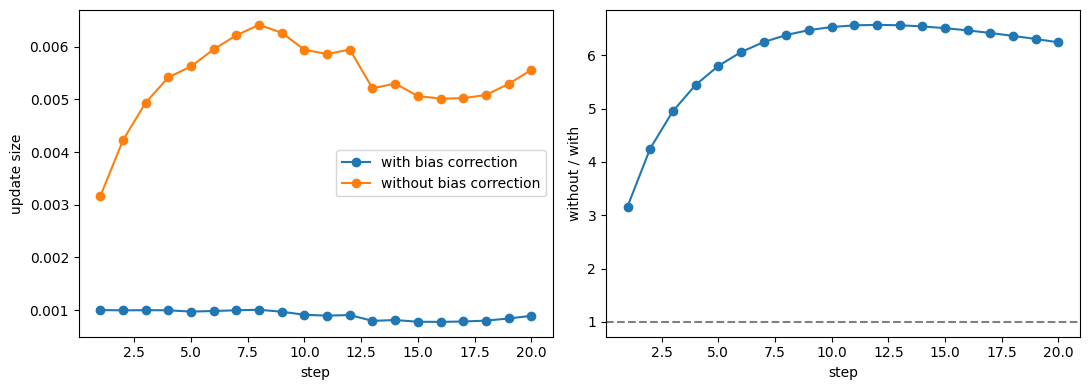

from formula: difference under 1% from step 3925
from simulation: difference under 1% from step 3925


In [3]:
def adam_steps(grads, bias_correction):
    m = v = 0.0
    steps = []
    for t, g in enumerate(grads, start=1):
        m = beta1 * m + (1 - beta1) * g
        v = beta2 * v + (1 - beta2) * g * g
        if bias_correction:
            m_use, v_use = m / (1 - beta1 ** t), v / (1 - beta2 ** t)
        else:
            m_use, v_use = m, v
        steps.append(lr * m_use / (math.sqrt(v_use) + eps))
    return steps


rng = np.random.default_rng(0)
grads20 = (1.0 + 0.5 * rng.standard_normal(20)).tolist()
with_bc = np.array(adam_steps(grads20, True))
without_bc = np.array(adam_steps(grads20, False))

steps_x = np.arange(1, 21)
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(steps_x, with_bc, "o-", label="with bias correction")
ax[0].plot(steps_x, without_bc, "o-", label="without bias correction")
ax[0].set_xlabel("step")
ax[0].set_ylabel("update size")
ax[0].legend()
ax[1].plot(steps_x, without_bc / with_bc, "o-")
ax[1].axhline(1, color="gray", ls="--")
ax[1].set_xlabel("step")
ax[1].set_ylabel("without / with")
plt.tight_layout()
plt.savefig("plots/part2_bias_correction.png")
plt.show()

# ignoring eps, without/with = (1 - beta1^t) / sqrt(1 - beta2^t) for any gradient sequence
t = 1
while abs((1 - beta1 ** t) / math.sqrt(1 - beta2 ** t) - 1) >= 0.01:
    t += 1
print("from formula: difference under 1% from step", t)

# same thing checked by simulation on a long gradient stream
long_grads = (1.0 + 0.5 * rng.standard_normal(10000)).tolist()
ratio = np.array(adam_steps(long_grads, False)) / np.array(adam_steps(long_grads, True))
print("from simulation: difference under 1% from step", np.argmax(np.abs(ratio - 1) < 0.01) + 1)

## Part 3-5 -  data, model, training loop

In [4]:
url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
if not os.path.exists("input.txt"):
    urllib.request.urlretrieve(url, "input.txt")
text = open("input.txt").read()

chars = sorted(set(text))
vocab_size = len(chars)
stoi = {c: i for i, c in enumerate(chars)}
data = torch.tensor([stoi[c] for c in text], dtype=torch.long)
n = int(0.9 * len(data))
train_data, val_data = data[:n], data[n:]

block_size = 128
batch_size = 32
n_layer = 2
n_head = 4


def get_batch():
    ix = torch.randint(len(train_data) - block_size - 1, (batch_size,))
    x = torch.stack([train_data[i:i + block_size] for i in ix])
    y = torch.stack([train_data[i + 1:i + block_size + 1] for i in ix])
    return x.to(device), y.to(device)


class Block(nn.Module):
    def __init__(self, d):
        super().__init__()
        self.ln1 = nn.LayerNorm(d)
        self.qkv = nn.Linear(d, 3 * d, bias=False)
        self.proj = nn.Linear(d, d, bias=False)
        self.ln2 = nn.LayerNorm(d)
        self.fc = nn.Linear(d, 4 * d, bias=False)
        self.fc_out = nn.Linear(4 * d, d, bias=False)

    def forward(self, x):
        B, T, C = x.shape
        q, k, v = self.qkv(self.ln1(x)).split(C, dim=2)
        q = q.view(B, T, n_head, C // n_head).transpose(1, 2)
        k = k.view(B, T, n_head, C // n_head).transpose(1, 2)
        v = v.view(B, T, n_head, C // n_head).transpose(1, 2)
        y = F.scaled_dot_product_attention(q, k, v, is_causal=True)
        y = y.transpose(1, 2).contiguous().view(B, T, C)
        x = x + self.proj(y)
        x = x + self.fc_out(F.gelu(self.fc(self.ln2(x))))
        return x


class GPT(nn.Module):
    def __init__(self, width):
        super().__init__()
        self.tok = nn.Embedding(vocab_size, width)
        self.pos = nn.Embedding(block_size, width)
        self.blocks = nn.ModuleList([Block(width) for _ in range(n_layer)])
        self.ln_f = nn.LayerNorm(width)
        self.head = nn.Linear(width, vocab_size, bias=False)

    def forward(self, idx, targets):
        T = idx.shape[1]
        x = self.tok(idx) + self.pos(torch.arange(T, device=idx.device))
        for block in self.blocks:
            x = block(x)
        logits = self.head(self.ln_f(x))
        return F.cross_entropy(logits.view(-1, vocab_size), targets.view(-1))


# fixed validation batches so every run is scored on the same data
eval_gen = torch.Generator().manual_seed(1)
eval_starts = torch.randint(len(val_data) - block_size - 1, (20 * batch_size,), generator=eval_gen)


@torch.no_grad()
def eval_loss(model):
    model.eval()
    loss_sum = 0.0
    for i in range(0, len(eval_starts), batch_size):
        ix = eval_starts[i:i + batch_size]
        x = torch.stack([val_data[j:j + block_size] for j in ix]).to(device)
        y = torch.stack([val_data[j + 1:j + block_size + 1] for j in ix]).to(device)
        loss_sum += model(x, y).item()
    model.train()
    return loss_sum / (len(eval_starts) // batch_size)


def train(width, lr_fn, steps, log_ratio=False):
    torch.manual_seed(0)  # same init and same batches for every run
    model = GPT(width).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr_fn(0))
    # ratio only for weight matrices; layernorm biases start at zero so the ratio is undefined
    ratios = {name: [] for name, p in model.named_parameters() if p.dim() == 2}
    losses = []
    for step in range(steps):
        for group in opt.param_groups:
            group["lr"] = lr_fn(step)
        x, y = get_batch()
        loss = model(x, y)
        opt.zero_grad(set_to_none=True)
        loss.backward()
        if log_ratio:
            before = {name: p.detach().clone() for name, p in model.named_parameters() if name in ratios}
        opt.step()
        if log_ratio:
            for name, p in model.named_parameters():
                if name in ratios:
                    ratios[name].append(((p.detach() - before[name]).norm() / before[name].norm()).item())
        losses.append(loss.item())
    return model, losses, ratios


warmup_steps = 100
total_steps = 300
peak_lr = 1e-3

## Part 3- Update-to-weight ratio per layer through warmup

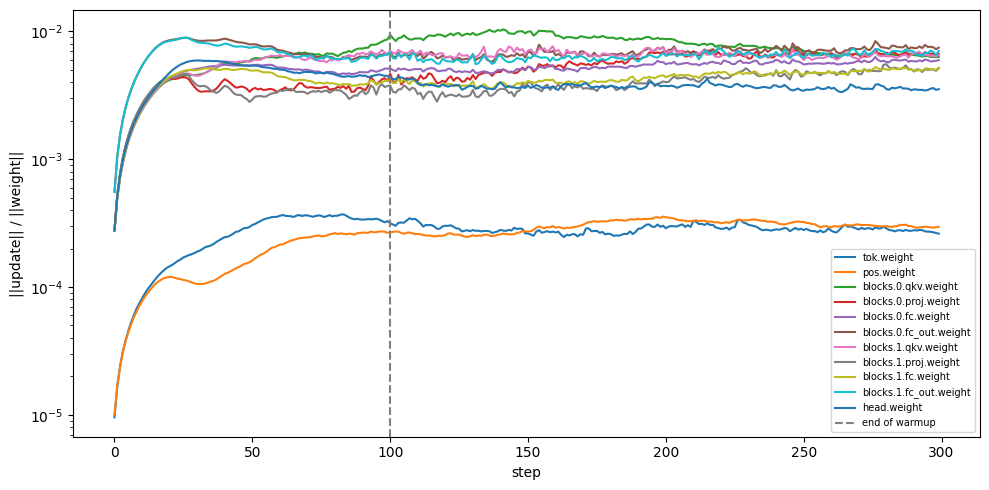

layer                     settles at step
tok.weight                None
pos.weight                None
blocks.0.qkv.weight       None
blocks.0.proj.weight      196
blocks.0.fc.weight        197
blocks.0.fc_out.weight    286
blocks.1.qkv.weight       260
blocks.1.proj.weight      None
blocks.1.fc.weight        None
blocks.1.fc_out.weight    200
head.weight               225

all layers settled by step: not all layers settled


In [5]:
# linear warmup then constant, so warmup is the only thing moving the lr
warmup_lr = lambda s: peak_lr * min(1.0, (s + 1) / warmup_steps)
model, losses, ratios = train(256, warmup_lr, total_steps, log_ratio=True)


def settle_step(r, window=10, tol=0.05):
    # plateau = mean of the last 100 steps; settled = smoothed ratio stays within 5% of it from here on
    r = np.array(r)
    smooth = np.convolve(r, np.ones(window) / window, mode="valid")  # smooth[i] is the mean of r[i : i+window]
    plateau = r[-100:].mean()
    outside = np.where(np.abs(smooth - plateau) > tol * plateau)[0]
    if len(outside) == 0:
        return 0
    if outside[-1] == len(smooth) - 1:
        return None  # never settled
    return outside[-1] + window


plt.figure(figsize=(10, 5))
settled = {}
for name, r in ratios.items():
    plt.plot(r, label=name)
    settled[name] = settle_step(r)
plt.axvline(warmup_steps, color="gray", ls="--", label="end of warmup")
plt.yscale("log")
plt.xlabel("step")
plt.ylabel("||update|| / ||weight||")
plt.legend(fontsize=7)
plt.tight_layout()
plt.savefig("plots/part3_update_ratio.png")
plt.show()

print(f"{'layer':25s} settles at step")
for name, s in settled.items():
    print(f"{name:25s} {s}")
valid = [s for s in settled.values() if s is not None]
print("\nall layers settled by step:", max(valid) if len(valid) == len(settled) else "not all layers settled")

## Part 4 - Cosine vs WSD, planned for 300 steps, stopped at 200


cosine  best peak lr=5.88e-03  train loss (last 10 avg)=1.9036  val loss=1.9853
wsd     best peak lr=5.88e-03  train loss (last 10 avg)=1.9131  val loss=2.0098


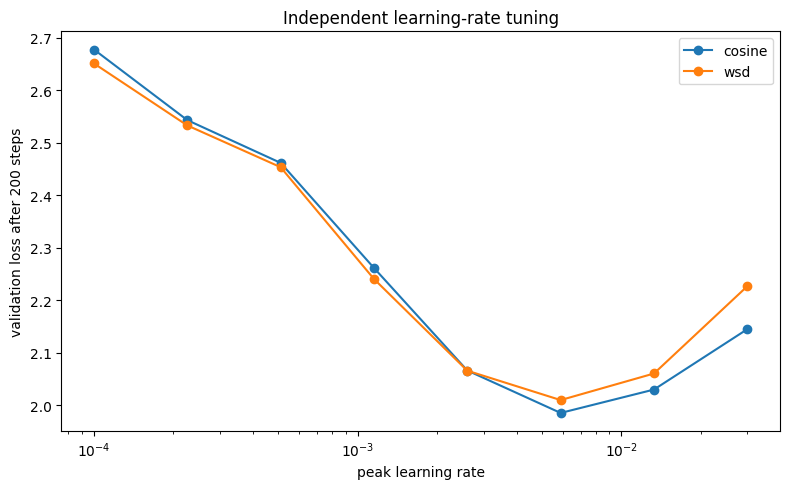

In [6]:
# Part 4: define the schedules
def cosine_lr(step, peak):
    if step < warmup_steps:
        return peak * (step + 1) / warmup_steps
    progress = (step - warmup_steps) / (total_steps - warmup_steps)
    return peak * (0.1 + 0.9 * 0.5 * (1 + math.cos(math.pi * progress)))


def wsd_lr(step, peak):
    decay_start = int(0.8 * total_steps)
    if step < warmup_steps:
        return peak * (step + 1) / warmup_steps
    if step < decay_start:
        return peak
    progress = (step - decay_start) / (total_steps - decay_start)
    return peak * (1 - 0.9 * progress)


stop_at = 200

# Tune each schedule independently using the same width, seed, data, and
# comparison horizon. Validation loss at step 200 is the selection metric.
tuning_lrs = np.logspace(-4, math.log10(3e-2), 8)
tuning_results = {"cosine": [], "wsd": []}

for name, fn in [("cosine", cosine_lr), ("wsd", wsd_lr)]:
    for candidate_lr in tuning_lrs:
        model, losses, _ = train(
            width=256,
            lr_fn=lambda s, peak=candidate_lr, schedule=fn: schedule(s, peak),
            steps=stop_at
        )
        tuning_results[name].append({
            "lr": candidate_lr,
            "val": eval_loss(model),
            "train_last10": np.mean(losses[-10:])
        })

best_schedule_lrs = {}
for name in ["cosine", "wsd"]:
    best = min(tuning_results[name], key=lambda x: x["val"])
    best_schedule_lrs[name] = best["lr"]
    print(
        f"{name:7s} best peak lr={best['lr']:.2e}  "
        f"train loss (last 10 avg)={best['train_last10']:.4f}  "
        f"val loss={best['val']:.4f}"
    )

fig, ax = plt.subplots(figsize=(8, 5))
for name in ["cosine", "wsd"]:
    xs = [r["lr"] for r in tuning_results[name]]
    ys = [r["val"] for r in tuning_results[name]]
    ax.plot(xs, ys, "o-", label=name)
ax.set_xscale("log")
ax.set_xlabel("peak learning rate")
ax.set_ylabel("validation loss after 200 steps")
ax.set_title("Independent learning-rate tuning")
ax.legend()
plt.tight_layout()
plt.savefig("plots/part4_lr_tuning.png")
plt.show()


cosine  peak lr=5.88e-03  lr at step 200=3.28e-03  train loss (last 10 avg)=1.9000  val loss=1.9771
wsd     peak lr=5.88e-03  lr at step 200=5.88e-03  train loss (last 10 avg)=1.9127  val loss=2.0095


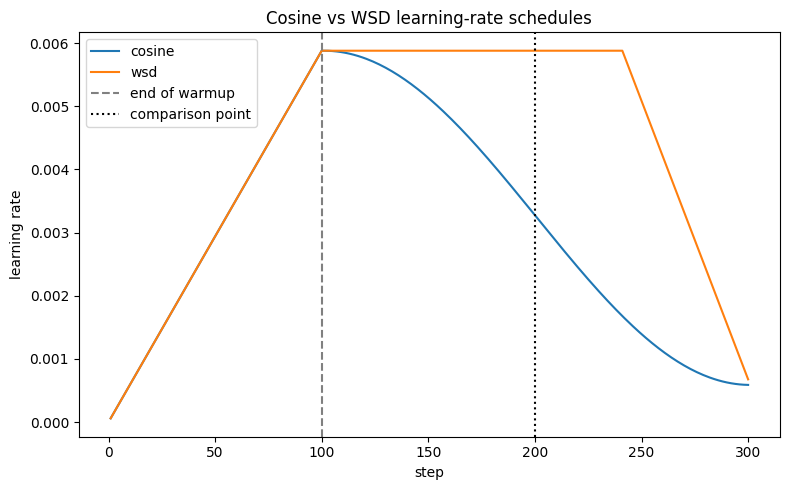

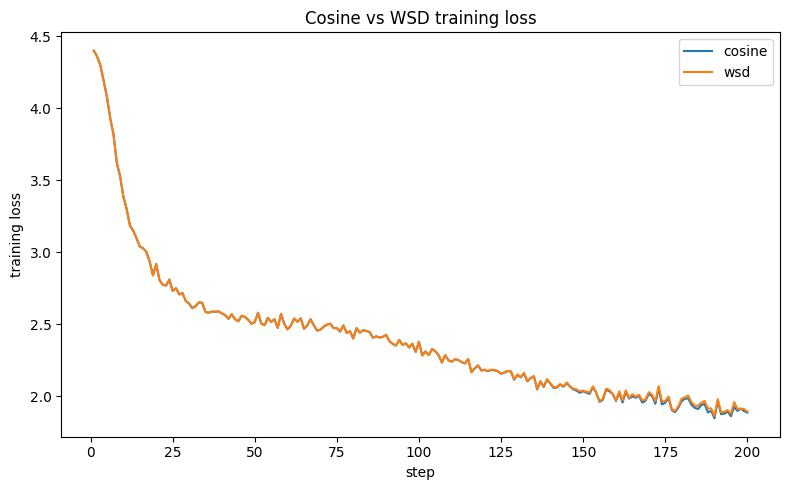


Winner at step 200: COSINE
Validation loss: 1.9771


In [7]:
# Part 4: final comparison with independently tuned peak learning rates
results = {}

for name, fn in [("cosine", cosine_lr), ("wsd", wsd_lr)]:
    tuned_peak_lr = best_schedule_lrs[name]
    model, losses, _ = train(
        width=256,
        lr_fn=lambda s, peak=tuned_peak_lr, schedule=fn: schedule(s, peak),
        steps=stop_at
    )
    results[name] = {
        "peak_lr": tuned_peak_lr,
        "losses": losses,
        "val": eval_loss(model),
        "lr_at_stop": fn(stop_at - 1, tuned_peak_lr)
    }

for name, r in results.items():
    print(
        f"{name:7s} peak lr={r['peak_lr']:.2e}  "
        f"lr at step {stop_at}={r['lr_at_stop']:.2e}  "
        f"train loss (last 10 avg)={np.mean(r['losses'][-10:]):.4f}  "
        f"val loss={r['val']:.4f}"
    )

fig, ax = plt.subplots(figsize=(8, 5))
steps_plot = np.arange(1, total_steps + 1)
for name, fn in [("cosine", cosine_lr), ("wsd", wsd_lr)]:
    peak = best_schedule_lrs[name]
    ax.plot(
        steps_plot,
        [fn(s - 1, peak) for s in steps_plot],
        label=name
    )
ax.axvline(warmup_steps, color="gray", ls="--", label="end of warmup")
ax.axvline(stop_at, color="black", ls=":", label="comparison point")
ax.set_xlabel("step")
ax.set_ylabel("learning rate")
ax.set_title("Cosine vs WSD learning-rate schedules")
ax.legend()
plt.tight_layout()
plt.savefig("plots/part4_lr_schedules.png")
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
for name in ["cosine", "wsd"]:
    ax.plot(
        np.arange(1, stop_at + 1),
        results[name]["losses"],
        label=name
    )
ax.set_xlabel("step")
ax.set_ylabel("training loss")
ax.set_title("Cosine vs WSD training loss")
ax.legend()
plt.tight_layout()
plt.savefig("plots/part4_training_loss.png")
plt.show()

winner = min(results, key=lambda name: results[name]["val"])
print(f"\nWinner at step {stop_at}: {winner.upper()}")
print(f"Validation loss: {results[winner]['val']:.4f}")


## Part 5 - LR sweep at widths 256, 512, 1024

width=  256  lr=1.0e-04  val loss=2.6336
width=  256  lr=3.1e-04  val loss=2.4861
width=  256  lr=9.8e-04  val loss=2.2113
width=  256  lr=3.1e-03  val loss=1.9283
width=  256  lr=9.6e-03  val loss=1.8526
width=  256  lr=3.0e-02  val loss=2.0909
width=  512  lr=1.0e-04  val loss=2.4987
width=  512  lr=3.1e-04  val loss=2.2696
width=  512  lr=9.8e-04  val loss=1.9771
width=  512  lr=3.1e-03  val loss=1.8265
width=  512  lr=9.6e-03  val loss=2.0921
width=  512  lr=3.0e-02  val loss=2.5412
width= 1024  lr=1.0e-04  val loss=2.3266
width= 1024  lr=3.1e-04  val loss=2.0119
width= 1024  lr=9.8e-04  val loss=1.8659
width= 1024  lr=3.1e-03  val loss=1.8647
width= 1024  lr=9.6e-03  val loss=2.4945
width= 1024  lr=3.0e-02  val loss=2.8116


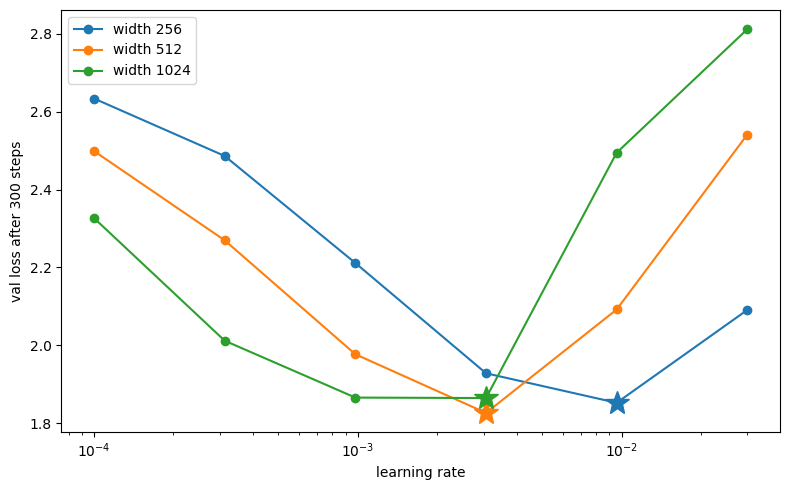

width   256: best lr 9.6e-03
width   512: best lr 3.1e-03
width  1024: best lr 3.1e-03

slope of log(best lr) vs log(width): -0.82
extrapolated lr at width 4096: 8.1e-04


In [8]:
widths = [256, 512, 1024]
lrs = np.logspace(-4, math.log10(3e-2), 6)
sweep = {}
for width in widths:
    sweep[width] = []
    for peak in lrs:
        model, _, _ = train(width, lambda s: cosine_lr(s, peak), total_steps)
        vl = eval_loss(model)
        sweep[width].append(vl)
        print(f"width={width:5d}  lr={peak:.1e}  val loss={vl:.4f}")

best_lrs = []
plt.figure(figsize=(8, 5))
for width in widths:
    line, = plt.plot(lrs, sweep[width], "o-", label=f"width {width}")
    i = np.nanargmin(sweep[width])
    best_lrs.append(lrs[i])
    plt.plot(lrs[i], sweep[width][i], "*", markersize=18, color=line.get_color())
plt.xscale("log")
plt.xlabel("learning rate")
plt.ylabel("val loss after 300 steps")
plt.legend()
plt.tight_layout()
plt.savefig("plots/part5_lr_sweep.png")
plt.show()

for width, b in zip(widths, best_lrs):
    print(f"width {width:5d}: best lr {b:.1e}")

# straight line through log2(best lr) vs log2(width), extended to 4096
slope, intercept = np.polyfit(np.log2(widths), np.log2(best_lrs), 1)
lr_4096 = 2 ** (slope * np.log2(4096) + intercept)
print(f"\nslope of log(best lr) vs log(width): {slope:.2f}")
print(f"extrapolated lr at width 4096: {lr_4096:.1e}")